In [2]:
# Haetaan peruskirjastot
import pandas as pd
import numpy as np

# Tiedostojenkäsittely useaa CSV:tä varten
import os
import glob

# Visualisointi
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from PIL import Image

# Aikavyöhykkeet ja aikaleimakäsittely
from datetime import datetime

In [ ]:
# Hakemistot
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)

raw_path = os.path.join(project_root, "data", "raw")
processed_path = os.path.join(project_root, "data", "processed")

# Store config
import sys
sys.path.append(os.path.join(project_root, "config"))
from store_config import store_config

# Tiedostot
raw_files = sorted(glob.glob(os.path.join(raw_path, "*.csv")))
processed_files = sorted(glob.glob(os.path.join(processed_path, "*.parquet")))

# Myymäläalueen koordinaattiarvot
store_max_x = store_config["geometry"]["store_max_x_cm"]
store_max_y = store_config["geometry"]["store_max_y_cm"]

print(f"Nykyinen hakemisto: {current_dir}")
print(f"Raw-tiedostoja: {len(raw_files)}")
print(f"Processed-tiedostoja: {len(processed_files)}")
print(f"Myymälän koko: {store_max_x} x {store_max_y} cm")

✅ Tiukennetut asetukset ladattu
Nykyinen hakemisto: /home/suviniemittm25sai/code/projektiopinnot-1-datan-hallinta-laitetaan-parastamme/notebooks
Raw-tiedostoja: 31
Processed-tiedostoja: 21
Myymälän koko: 11206 x 5220 cm


### 1. Tutkitaan mitkä kärryt on poistettu

In [4]:
# Poimitaan node-nimet tiedostonimistä
raw_nodes = set(os.path.basename(f).replace(".csv", "") for f in raw_files)
processed_nodes = set(os.path.basename(f).replace(".parquet", "") for f in processed_files)

# Mitkä kärryt puuttuvat processed-kansiosta?
missing = sorted(raw_nodes - processed_nodes)

print(f"Siivouksessa poistetut kärryt ({len(missing)} kpl):")
for node in missing:
    print(f"  {node}")

Siivouksessa poistetut kärryt (10 kpl):
  node_42787
  node_45300
  node_51720
  node_52008
  node_53000
  node_53027
  node_53768
  node_53795
  node_53888
  node_64458


### Poistetut kärryt
- 31 kärrystä 10 on poistettu kokonaan siivousvaiheessa
- Poistetut kärryt: node_42787, node_45300, node_51720, node_52008, node_53000, 
  node_53027, node_53768, node_53795, node_53888, node_64458

### 2. Tutkitaan datapisteiden osuus myymälän ulkopuolella

In [ ]:
# Poistetut kärryt
missing_nodes = sorted(raw_nodes - processed_nodes)
results = []

for node_name in missing_nodes:
    filepath = os.path.join(raw_path, f"{node_name}.csv")
    df = pd.read_csv(
        filepath,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "quality": float, "z": float}
    )
    
    total = len(df)
    outside = ((df["x"] < 0) | (df["x"] > store_max_x) | 
               (df["y"] < 0) | (df["y"] > store_max_y)).sum()
    
    results.append({
        "node": node_name,
        "rivejä_yhteensä": total,
        "koordinaatit_ulkopuolella": outside,
        "ulkopuolella_%": round(outside / total * 100, 1)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      node  rivejä_yhteensä  koordinaatit_ulkopuolella  ulkopuolella_%
node_42787                8                          3            37.5
node_45300                1                          1           100.0
node_51720              216                         19             8.8
node_52008               44                         19            43.2
node_53000              182                         53            29.1
node_53027              597                        115            19.3
node_53768              421                         56            13.3
node_53795              671                        132            19.7
node_53888              592                         84            14.2
node_64458                1                          1           100.0


### Poiston syy: dataa pelkästään myymäläalueen ulkopuolella
- node_45300, node_64458: vain 1 datapiste ja se on myymälän ulkopuolella

### 3. Tutkitaan kuinka moni datapiste ei muodosta sessiota kriteerien mukaisesti

In [6]:
def split_sessions(df, gap_threshold_s=300, min_points=2):
    """Pilkkoo yhden kärryn datan erillisiksi sessioiksi aikaeron perusteella."""
    
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["time_diff_s"] = df["timestamp"].diff().dt.total_seconds()
    df["session_id"] = (df["time_diff_s"] > gap_threshold_s).cumsum()
    
    # Poistetaan sessiot joissa alle min_points pistettä
    session_sizes = df.groupby("session_id")["session_id"].transform("count")
    df = df[session_sizes >= min_points].reset_index(drop=True)
    
    return df

In [7]:
# Haetaan tiedot kaikista poistetuista kärryistä
def analyze_removed_node(node_name, raw_path, store_config):
    
    store_max_x = store_config["geometry"]["store_max_x_cm"]
    store_max_y = store_config["geometry"]["store_max_y_cm"]
    min_points = store_config["session_logic"]["min_points"]
    gap_threshold_s = store_config["session_logic"]["gap_threshold_s"]
    
    entrance = store_config["spatial_zones"]["gates"]["sisäänkäynti"]["coords"]
    ex_min, ex_max, ey_min, ey_max = entrance
    
    checkout = store_config["spatial_zones"]["gates"]["kassa"]["coords"]
    cx_min, cx_max, cy_min, cy_max = checkout

    filepath = os.path.join(raw_path, f"{node_name}.csv")
    df = pd.read_csv(
        filepath,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "quality": float, "z": float}
    )
    
    # Tallennetaan alkuperäinen rivimäärä ja lasketaan outside ENNEN suodatusta
    total_original = len(df)
    outside = ((df["x"] < 0) | (df["x"] > store_max_x) |
               (df["y"] < 0) | (df["y"] > store_max_y)).sum()
    
    # Pilkotaan sessioihin suodatuksen jälkeen
    df = split_sessions(df, gap_threshold_s)
    sessions = df.groupby("session_id") if len(df) > 0 else []
    
    valid_sessions = 0
    for _, session in sessions:
        if len(session) < min_points:
            continue
        first = session.iloc[0]
        last = session.iloc[-1]
        starts_ok = (ex_min <= first["x"] <= ex_max) and (ey_min <= first["y"] <= ey_max)
        ends_ok = (cx_min <= last["x"] <= cx_max) and (cy_min <= last["y"] <= cy_max)
        if starts_ok and ends_ok:
            valid_sessions += 1
    
    # Käytetään alkuperäistä rivimäärää prosenttilaskussa
    ulkona_pct = round(outside / total_original * 100, 1) if total_original > 0 else 0.0

    return {
        "node": node_name,
        "rivejä_alkup": total_original,
        "sessioita": df["session_id"].nunique() if len(df) > 0 else 0,
        "koordinaatit_ulkopuolella_%": ulkona_pct,
        "validit_sessiot": valid_sessions,
        "syy_poistolle": "ei valideja sessioita" if valid_sessions == 0 else "muu syy"
    }

# Ajetaan kaikille poistetuille kärryille
summary = []
for node_name in missing_nodes:
    result = analyze_removed_node(node_name, raw_path, store_config)
    summary.append(result)

summary_df = pd.DataFrame(summary)
print("Poistettujen kärryjen analyysi:")
print()
print(summary_df.to_string(index=False))

Poistettujen kärryjen analyysi:

      node  rivejä_alkup  sessioita  koordinaatit_ulkopuolella_%  validit_sessiot         syy_poistolle
node_42787             8          0                         37.5                0 ei valideja sessioita
node_45300             1          0                        100.0                0 ei valideja sessioita
node_51720           216         43                          8.8                0 ei valideja sessioita
node_52008            44          4                         43.2                0 ei valideja sessioita
node_53000           182         39                         29.1                0 ei valideja sessioita
node_53027           597        125                         19.3                0 ei valideja sessioita
node_53768           421         86                         13.3                0 ei valideja sessioita
node_53795           671        144                         19.7                0 ei valideja sessioita
node_53888           592       

### Yhteenveto kärryjen poistosyistä

**1. Lähes tyhjä data 3/10:**
- Kahdessa kärryssä vain 1 datapiste, jotka 100 % myymälän ulkopuolella, ja yhdessä kärryssä vain 8 datapistettä, joista ei muodostu yhtään sessiota.

**2. Jonkin verran dataa mutta hajanainen signaali 3/10:**
- Kolmessa kärryssä jonkin verran dataa
- Sensorisignaali liian epäluotettava jatkuvaan seurantaan

**3. Enemmän dataa mutta yksikään sessio ei täytä kriteerejä 4/10:**
- Session kriteerit: ensimmäinen datapiste sisäänkäynnillä ja viimeinen kassalla, ≥ 50 datapistettä

### 4. Tutkitaan poistettujen kärryjen dataa

In [8]:
summary = []

for node_name in missing_nodes:
    filepath = os.path.join(raw_path, f"{node_name}.csv")
    df = pd.read_csv(
        filepath,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    
    summary.append({
        "node": node_name,
        "rivejä": len(df),
        "duplikaatit": df.duplicated().sum(),
        "x_min": df["x"].min(),
        "x_max": df["x"].max(),
        "y_min": df["y"].min(),
        "y_max": df["y"].max(),
        "q_min": df["q"].min(),
        "q_max": df["q"].max(),
        "q_mean": round(df["q"].mean(), 1)
    })
    
    del df

summary_df = pd.DataFrame(summary)
print(f"Rivejä yhteensä: {summary_df['rivejä'].sum()}")
print()
print(summary_df.to_string(index=False))

Rivejä yhteensä: 2733

      node  rivejä  duplikaatit    x_min   x_max    y_min    y_max  q_min  q_max  q_mean
node_42787       8            0 -32818.0 32716.0 -32718.0   3602.0   50.0  255.0   147.1
node_45300       1            0  30197.0 30197.0   2395.0   2395.0   70.0   70.0    70.0
node_51720     216            0 -23730.0  9714.0 -21336.0   3668.0   13.0  254.0    51.5
node_52008      44            0 -32047.0 32717.0 -32718.0   5050.0   41.0  255.0   173.0
node_53000     182            0   -605.0 27061.0 -23499.0   3681.0    1.0  254.0    55.7
node_53027     597            0 -32497.0 32717.0 -32718.0  25381.0    6.0  255.0    63.8
node_53768     421            0 -31818.0  6670.0    811.0   4023.0   12.0  255.0    55.0
node_53795     671            0   -645.0 28086.0 -29113.0  20266.0   29.0  255.0    54.8
node_53888     592            0 -22090.0 17334.0 -24192.0  21450.0   27.0  255.0    62.0
node_64458       1            0  -7125.0 -7125.0 -14064.0 -14064.0   74.0   74.0    74.

### 5. Visualisoidaan datapisteet myymälässä ja dead zones -alueilla

In [9]:
map_profile = store_config["geometry"]["map_profiles"]["default"]
scale = map_profile["scale_cm_per_px"]

img_x_min = -map_profile["origin_x_px"] * scale
img_x_max = (map_profile["width_px"] - map_profile["origin_x_px"]) * scale
img_y_min = -map_profile["origin_y_px"] * scale
img_y_max = (map_profile["height_px"] - map_profile["origin_y_px"]) * scale

EXT = [img_x_min, img_x_max, img_y_max, img_y_min]

In [10]:
# Kerätään poistettujen kärryjen pisteet
all_points = []
for node_name in missing_nodes:
    filepath = os.path.join(raw_path, f"{node_name}.csv")
    df = pd.read_csv(
        filepath,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    df["node"] = node_name
    all_points.append(df)
    del df

points_df = pd.concat(all_points, ignore_index=True)

# Suodatetaan myymälän rajoihin
points_viz = points_df[
    (points_df["x"] >= 0) & (points_df["x"] <= store_max_x) &
    (points_df["y"] >= 0) & (points_df["y"] <= store_max_y)
]

print(f"Pisteitä yhteensä: {len(points_df)}")
print(f"Pisteitä myymälän sisällä: {len(points_viz)}")
print(f"Pisteitä ulkona: {len(points_df) - len(points_viz)}")

Pisteitä yhteensä: 2733
Pisteitä myymälän sisällä: 2250
Pisteitä ulkona: 483


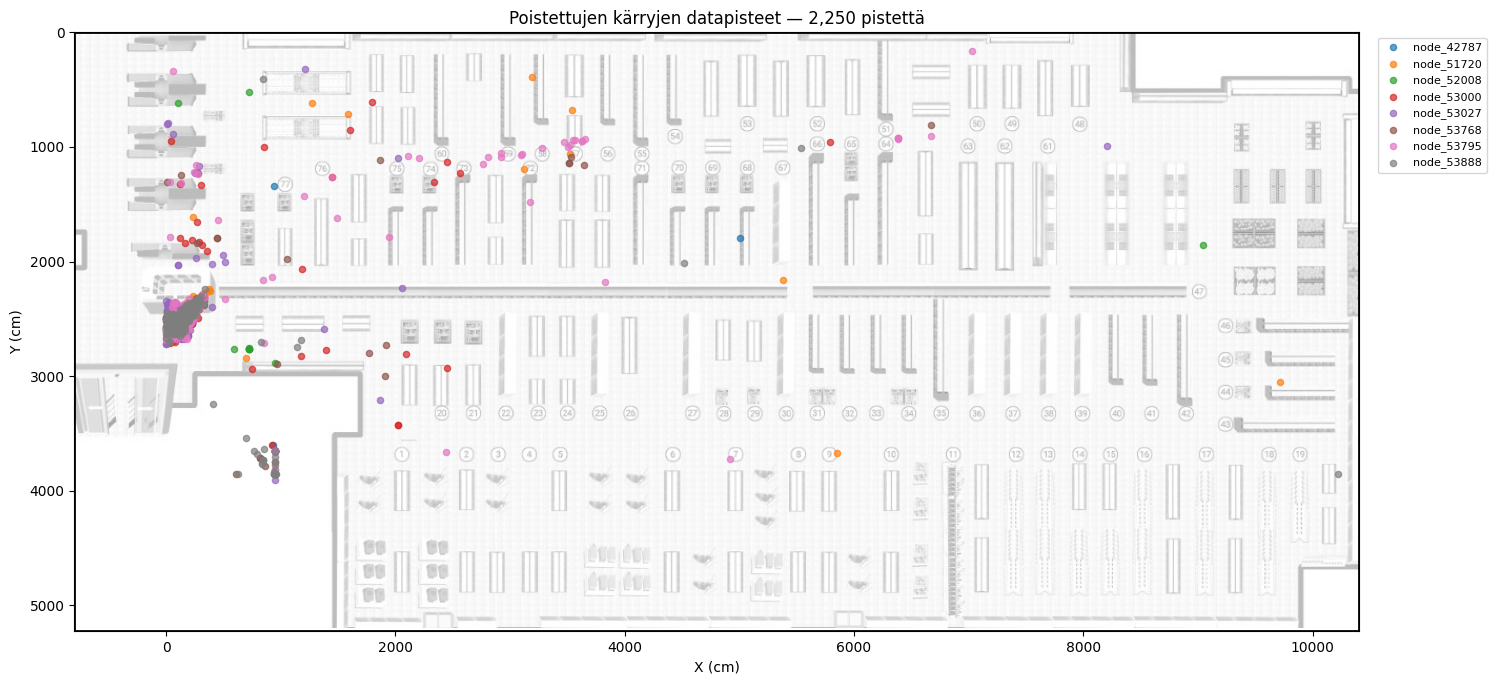

In [11]:
# Ladataan pohjakartta
img_path = os.path.join(project_root, "kauppa.jpg")
img = Image.open(img_path)

# Piirretään
fig, ax = plt.subplots(figsize=(15, 7))

ax.imshow(img, extent=EXT, aspect='equal', alpha=0.5)

# Pisteet värikoodattuna kärryn mukaan
for node_name in points_viz["node"].unique():
    node_data = points_viz[points_viz["node"] == node_name]
    ax.scatter(node_data["x"], node_data["y"], label=node_name, s=20, alpha=0.7)

# Myymälän rajat - aloitetaan kassalinjan sijaan myymälän reunasta
ax.plot([img_x_min, img_x_max, img_x_max, img_x_min, img_x_min], 
        [0, 0, store_max_y, store_max_y, 0], color='black', lw=2)

ax.set_xlim(img_x_min, img_x_max)
ax.set_ylim(store_max_y, 0)
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_title(f"Poistettujen kärryjen datapisteet — {len(points_viz):,} pistettä")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 6. Tarkistetaan päällekkäisten koordinaattien määrä myymälän sisällä

In [12]:
duplicated_coords = points_viz.duplicated(subset=["x", "y"]).sum()
print(f"Pisteitä yhteensä: {len(points_viz)}")
print(f"Päällekkäisiä koordinaatteja: {duplicated_coords}")
print(f"Uniikkeja koordinaatteja: {len(points_viz) - duplicated_coords}")
print()

# Mitkä koordinaatit toistuvat eniten
print("Yleisimmät koordinaatit:")
print(points_viz.groupby(["x", "y"]).size().sort_values(ascending=False).head(10))

Pisteitä yhteensä: 2250
Päällekkäisiä koordinaatteja: 266
Uniikkeja koordinaatteja: 1984

Yleisimmät koordinaatit:
x      y     
950.0  3850.0    15
       3650.0    11
31.0   2572.0     4
145.0  2623.0     4
232.0  2375.0     4
250.0  2411.0     4
239.0  2443.0     3
275.0  2383.0     3
944.0  3850.0     3
26.0   2463.0     3
dtype: int64


### 7. Visualisoidaan koordinaattijakauma

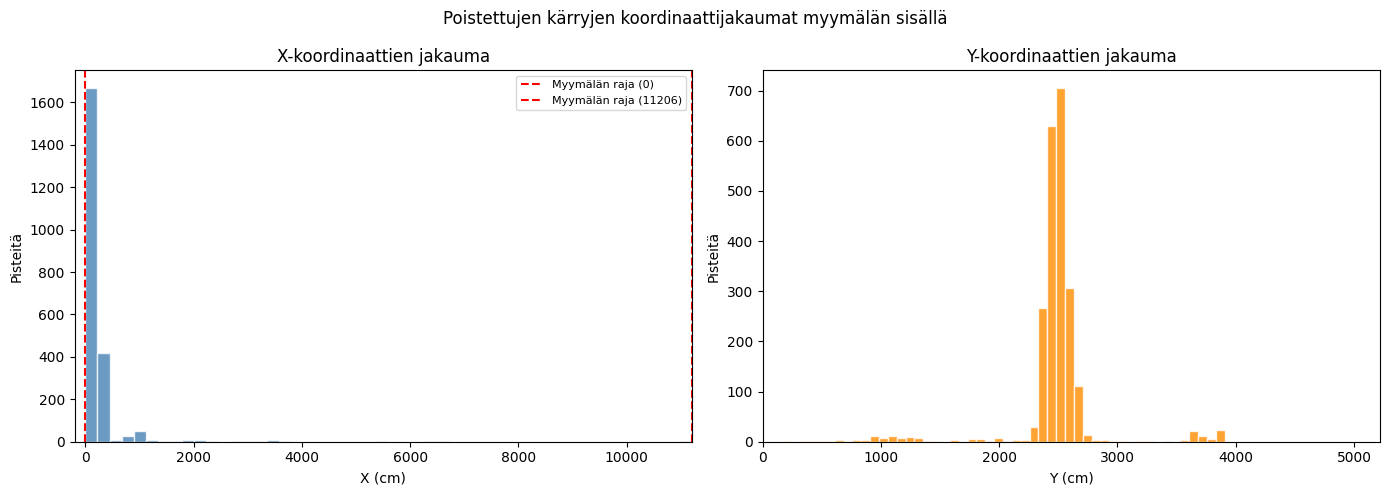

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X-koordinaattien jakauma
axes[0].hist(points_viz["x"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", lw=1.5, label="Myymälän raja (0)")
axes[0].set_xlabel("X (cm)")
axes[0].set_ylabel("Pisteitä")
axes[0].set_title("X-koordinaattien jakauma")
axes[0].legend(fontsize=8)
axes[0].set_xlim(-200, store_max_x)

# Y-koordinaattien jakauma
axes[1].hist(points_viz["y"], bins=50, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Y (cm)")
axes[1].set_ylabel("Pisteitä")
axes[1].set_title("Y-koordinaattien jakauma")
axes[1].set_xlim(0, store_max_y)

plt.suptitle("Poistettujen kärryjen koordinaattijakaumat myymälän sisällä")
plt.tight_layout()
plt.show()

### Yhteenveto poistettujen kärryjen datasta

Poistettujen kärryjen raakadatassa on yhteensä **2733 datapistettä** 10 kärryssä.
Ei duplikaatteja yhdelläkään kärryllä.

### Datapisteiden määrä
- Erittäin vähän dataa: node_45300 ja node_64458 (1 piste), node_42787 (8 pistettä)
- Kohtalaisesti dataa: node_52008 (44), node_53000 (182), node_51720 (216)
- Eniten dataa: node_53795 (671), node_53027 (597), node_53888 (592), node_53768 (421)

### Koordinaatit
Myymälän rajat: x = 0–11206 cm, y = 0–5220 cm

Kaikilla kärryillä esiintyy myymälän ulkopuolisia koordinaatteja:
- Pahimmat tapaukset: node_42787, node_52008, node_53027 — x-arvot jopa ±32000 cm
- node_53768 on ainoa kärry jonka x-koordinaatit pysyvät kohtuullisissa rajoissa

2733 pisteestä **2250 on myymälän sisällä** ja **483 ulkona (17.7%)**

### Signaalin laatu (q-arvo, max 255)
- Heikko signaali: node_53000 (q_min=1), node_53027 (q_min=6), node_53768 (q_min=12)
- Keskimääräinen laatu vaihtelee välillä 51–173
- node_42787 ja node_52008 korkein keskiarvo (147 ja 173) mutta liian vähän datapisteitä

### Koordinaattijakauma:

- X-koordinaatit: Yli 1600 pistettä kasautuu välille 0–500 cm eli sisään/uloskäynnin ja kassojen alueelle. Myymälän loppuosa (500–11 206 cm) lähes tyhjä
- Y-koordinaatit: Selvä piikki välillä 2000–3000, jossa sisään/uloskäynti ja info (y=2350–2975)
- Jakauma on kapea — pisteet eivät hajaudu tasaisesti myymälän leveyssuunnassa